# 04 — Compare MD and REFPROP Seitz thresholds

This notebook loads the physical MD states produced by notebook 02 and evaluates
SeitzModel at those exact temperatures and pressures.  It does not refit the Argon
scale or recalculate the MD EOS.

The comparison includes a raw matched table, a pressure overlay, a parity plot,
the MD/REFPROP ratio, and the REFPROP critical radius.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MD_REPO = Path.home() / "MDsims"
DATA_DIRECTORY = MD_REPO / "Argon" / "data"
MD_STATES_PATH = DATA_DIRECTORY / "md_seitz_states.csv"
SEITZ_REPO = Path.home() / "SeitzModel"
REFPROP_ROOT = SEITZ_REPO / "REFPROP"

assert MD_STATES_PATH.exists(), "Run notebook 02 first."
if str(REFPROP_ROOT) not in sys.path:
    sys.path.insert(0, str(REFPROP_ROOT))
from SeitzModel import SeitzModel

comparison = pd.read_csv(MD_STATES_PATH)
required = ["Run_ID", "T_K", "T_C", "P_bar", "P_psia", "Q_MD_keV", "Q_MD_uncertainty_keV"]
missing = [column for column in required if column not in comparison]
assert not missing, f"Missing MD columns: {missing}"
comparison[required]


,Run_ID,T_K,T_C,P_bar,P_psia,Q_MD_keV,Q_MD_uncertainty_keV
0,20260918194755,128.599551,-144.550449,1.403244,20.352328,0.020999,0.002130
1,20260918192601,128.599551,-144.550449,2.150527,31.190755,0.020793,0.002191
2,20260918192848,128.599551,-144.550449,3.579119,51.910727,0.031255,0.002265
3,20260918193606,128.599551,-144.550449,4.418197,64.080524,0.028375,0.003013
4,20260918195515,128.599551,-144.550449,4.755320,68.970083,0.038117,0.003080
5,20260918195040,128.599551,-144.550449,4.839212,70.186833,0.027475,0.003093
6,20260918194043,128.599551,-144.550449,5.536865,80.305436,0.040756,0.003125
7,20260918190731,128.599551,-144.550449,8.732729,126.657532,0.062057,0.003947
8,20260918191538,128.599551,-144.550449,8.921394,129.393882,0.073289,0.004028
9,20260918200708,128.599551,-144.550449,10.216672,148.180302,0.066929,0.003979


## Evaluate REFPROP at the exact MD states


In [2]:
reference = SeitzModel(
    comparison["P_psia"].to_numpy(dtype=float),
    comparison["T_C"].to_numpy(dtype=float),
    "ARGON",
    [1.0],
)

reference_fields = {
    "Q_REFPROP_keV": reference.Q,
    "Rc_REFPROP_nm": reference.Rc,
    "Pvap_REFPROP_psia": reference.Pvap,
    "Pbub_REFPROP_psia": reference.Pbub,
    "REFPROP_P_err_psia": reference.P_err,
    "REFPROP_G_err_J_kg": reference.G_err,
    "REFPROP_iterations": reference.interp_iterations,
    "REFPROP_errID": reference.errID,
}
for name, values in reference_fields.items():
    comparison[name] = np.asarray(values, dtype=object)
numeric = [name for name in reference_fields if name != "REFPROP_errID"]
comparison[numeric] = comparison[numeric].apply(pd.to_numeric, errors="coerce")

comparison["superheat_margin_psia"] = comparison["Pvap_REFPROP_psia"] - comparison["P_psia"]
comparison["Q_MD_over_REFPROP"] = comparison["Q_MD_keV"] / comparison["Q_REFPROP_keV"]
comparison["Q_difference_keV"] = comparison["Q_MD_keV"] - comparison["Q_REFPROP_keV"]
comparison["valid_REFPROP"] = (
    comparison["REFPROP_errID"].isna()
    & comparison["Q_REFPROP_keV"].gt(0)
    & comparison["Rc_REFPROP_nm"].gt(0)
    & comparison["superheat_margin_psia"].gt(0)
)

comparison[[
    "Run_ID", "T_K", "P_bar", "Q_MD_keV", "Q_MD_uncertainty_keV",
    "Q_REFPROP_keV", "Q_MD_over_REFPROP", "Rc_REFPROP_nm",
    "superheat_margin_psia", "REFPROP_errID",
]]


,Run_ID,T_K,P_bar,Q_MD_keV,Q_MD_uncertainty_keV,Q_REFPROP_keV,Q_MD_over_REFPROP,Rc_REFPROP_nm,superheat_margin_psia,REFPROP_errID
0,20260918194755,128.599551,1.403244,0.020999,0.002130,0.060659,0.346179,4.182055,254.266373,None
1,20260918192601,128.599551,2.150527,0.020793,0.002191,0.066975,0.310455,4.369037,243.427945,None
2,20260918192848,128.599551,3.579119,0.031255,0.002265,0.082158,0.380424,4.777166,222.707974,None
3,20260918193606,128.599551,4.418197,0.028375,0.003013,0.093610,0.303119,5.054338,210.538176,None
4,20260918195515,128.599551,4.755320,0.038117,0.003080,0.098892,0.385438,5.174941,205.648617,None
5,20260918195040,128.599551,4.839212,0.027475,0.003093,0.100276,0.273992,5.205849,204.431867,None
6,20260918194043,128.599551,5.536865,0.040756,0.003125,0.112986,0.360718,5.477883,194.313264,None
7,20260918190731,128.599551,8.732729,0.062057,0.003947,0.217617,0.285167,7.199764,147.961169,None
8,20260918191538,128.599551,8.921394,0.073289,0.004028,0.227814,0.321708,7.335780,145.224819,None
9,20260918200708,128.599551,10.216672,0.066929,0.003979,0.321120,0.208425,8.428572,126.438398,None


## Visual comparison


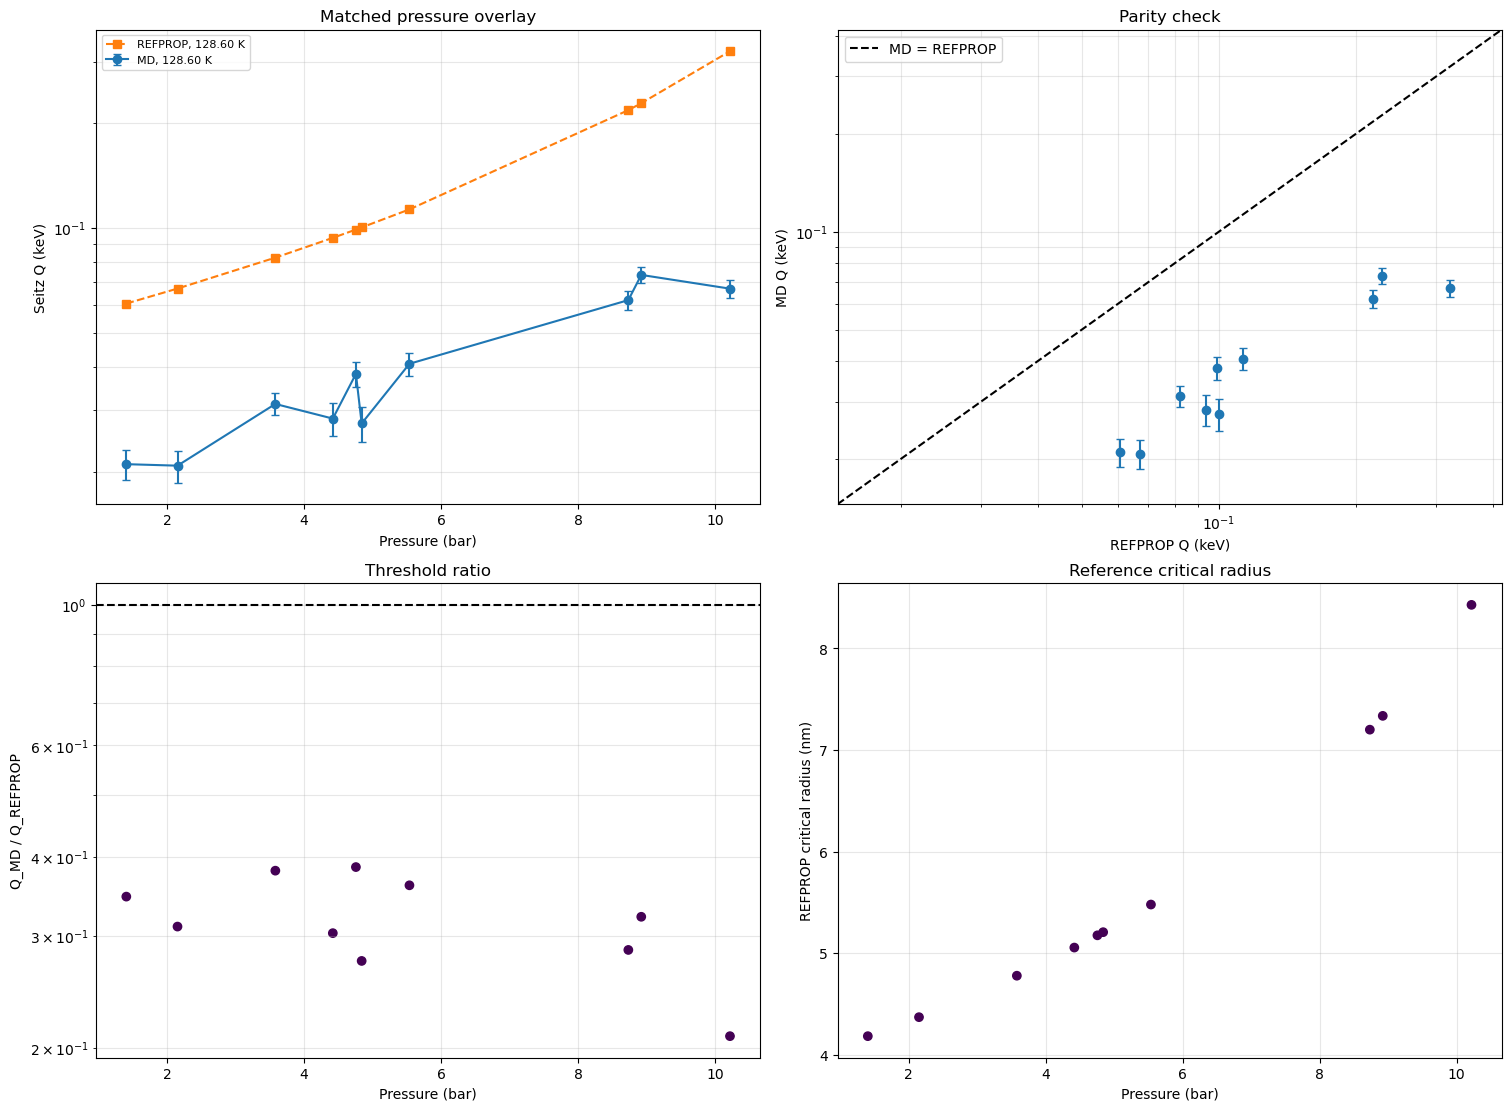

In [5]:
valid = comparison.loc[comparison["valid_REFPROP"]].copy()
fig, axes = plt.subplots(2, 2, figsize=(15, 11), constrained_layout=True)

for temperature, group in valid.groupby("T_K"):
    group = group.sort_values("P_bar")
    axes[0, 0].errorbar(group["P_bar"], group["Q_MD_keV"],
                        yerr=group["Q_MD_uncertainty_keV"], marker="o", capsize=3,
                        label=f"MD, {temperature:.2f} K")
    axes[0, 0].plot(group["P_bar"], group["Q_REFPROP_keV"], "s--",
                    label=f"REFPROP, {temperature:.2f} K")
axes[0, 0].set(xlabel="Pressure (bar)", ylabel="Seitz Q (keV)", title="Matched pressure overlay", yscale="log")
axes[0, 0].legend(fontsize=8)

axes[0, 1].errorbar(valid["Q_REFPROP_keV"], valid["Q_MD_keV"],
                    yerr=valid["Q_MD_uncertainty_keV"], fmt="o", capsize=3)
limits = [min(valid["Q_REFPROP_keV"].min(), valid["Q_MD_keV"].min()) * 0.7,
          max(valid["Q_REFPROP_keV"].max(), valid["Q_MD_keV"].max()) * 1.3]
axes[0, 1].plot(limits, limits, "k--", label="MD = REFPROP")
axes[0, 1].set(xlabel="REFPROP Q (keV)", ylabel="MD Q (keV)", title="Parity check",
               xscale="log", yscale="log", xlim=limits, ylim=limits)
axes[0, 1].legend()

axes[1, 0].axhline(1, color="black", linestyle="--")
axes[1, 0].scatter(valid["P_bar"], valid["Q_MD_over_REFPROP"], c=valid["T_K"], cmap="viridis")
axes[1, 0].set(xlabel="Pressure (bar)", ylabel="Q_MD / Q_REFPROP", title="Threshold ratio", yscale="log")

axes[1, 1].scatter(valid["P_bar"], valid["Rc_REFPROP_nm"], c=valid["T_K"], cmap="viridis")
axes[1, 1].set(xlabel="Pressure (bar)", ylabel="REFPROP critical radius (nm)", title="Reference critical radius")

for axis in axes.flat:
    axis.grid(alpha=0.3, which="both")
plt.show()


## Summary and saved comparison


In [6]:
summary = pd.Series({
    "matched_states": len(comparison),
    "valid_REFPROP_states": int(comparison["valid_REFPROP"].sum()),
    "temperatures_K": sorted(comparison["T_K"].unique()),
    "pressure_min_bar": comparison["P_bar"].min(),
    "pressure_max_bar": comparison["P_bar"].max(),
    "Q_MD_min_keV": comparison["Q_MD_keV"].min(),
    "Q_MD_max_keV": comparison["Q_MD_keV"].max(),
    "Q_REFPROP_min_keV": comparison["Q_REFPROP_keV"].min(),
    "Q_REFPROP_max_keV": comparison["Q_REFPROP_keV"].max(),
    "ratio_min": comparison["Q_MD_over_REFPROP"].min(),
    "ratio_max": comparison["Q_MD_over_REFPROP"].max(),
})
summary


matched_states                           10
valid_REFPROP_states                     10
temperatures_K          [128.5995507884122]
pressure_min_bar                   1.403244
pressure_max_bar                  10.216672
Q_MD_min_keV                       0.020793
Q_MD_max_keV                       0.073289
Q_REFPROP_min_keV                  0.060659
Q_REFPROP_max_keV                   0.32112
ratio_min                          0.208425
ratio_max                          0.385438
dtype: object

In [7]:
output_path = DATA_DIRECTORY / "md_refprop_seitz_comparison.csv"
comparison.to_csv(output_path, index=False)
print("Saved:", output_path)


Saved: /home/pnichols/MDsims/Argon/data/md_refprop_seitz_comparison.csv
